# <b> CRBL MF v25 REV 02</b>

<b> authors: Roberta Maria Lorenzi </b>

<b> version 1) - Integration of PLV weigths -  July, 2025</b>

contacts: robertamaria.lorenzi01@universitadipavia.it

## What is new?
Update version of Cerebellar mean-field (CRBL-MF v25) based on a mouse-awake configurations.
Pipeline for deriving mean-field parameters from SNN is authomatized:
- Synaptic convergence is weighted for PLV
- Quantal synaptic convergence and Synaptic time decay are cmputed as the average fo multiple synaptic conenction in SNN.



## Mean field model simulations

Testing

In [1]:
#import the libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from plot_utils import *
import sys
sys.path.append('../')
import os
from scipy.signal import find_peaks

from load_config_TF import *
from master_equation_CRBL_MF import *
from theoretical_tools import *

In [2]:
def load_my_file(filename, sigma=0.05, amp=50):
    data_txt = np.loadtxt(filename+str(sigma)+'_'+str(amp)+".txt")
    inp_txt = data_txt[:, 0]
    mfm_pred_txt = data_txt[:, 1:]
    mfm_pred_PC = mfm_pred_txt[:,10]
    
    return mfm_pred_txt, mfm_pred_PC, inp_txt

In [3]:
dt = 1e-4
sim_len = 0.5
t = np.arange(0, sim_len, dt)

In [1]:
base_path = 'gaussian_input_output/'
base_name = 'gaussian_input'
data_001_50, PC_001_50, inp_txt_001_50 = load_my_file(base_path+base_name, 0.01, 50)
data_001_100, PC_001_100, inp_txt_001_100 = load_my_file(base_path+base_name, 0.01, 100)
data_001_150, PC_001_150,inp_txt_001_150 = load_my_file(base_path+base_name,0.01, 150)

data_005_50, PC_005_50, inp_txt_005_50 = load_my_file(base_path+base_name, 0.05, 50)
data_005_100, PC_005_100, inp_txt_005_100 = load_my_file(base_path+base_name, 0.05, 100)
data_005_150, PC_005_150, inp_txt_005_150 = load_my_file(base_path+base_name, 0.05, 150)

data_01_50, PC_01_50, inp_txt_01_50 = load_my_file(base_path+base_name, 0.1, 50)
data_01_100, PC_01_100, inp_txt_01_100 = load_my_file(base_path+base_name, 0.1, 100)
data_01_150, PC_01_150, inp_txt_01_150 = load_my_file(base_path+base_name, 0.1, 150)

NameError: name 'load_my_file' is not defined

In [5]:
def peak_analysis(signal, prominence, t, ttrans, color = 'green', color_peak = 'black', name_fig = 'peak', save_img = True):
    
    t = t[ttrans:]
    signal_notrans = signal[ttrans:] #to avoid that first point after transient is considered as a peak
    peaks, _ = find_peaks(signal_notrans, prominence = prominence)

    peak_act  = signal_notrans[peaks]
    print('PeaksHz', peak_act)
    
    peak_max = peaks[np.argmax(signal_notrans[peaks])]
    max_act = round(signal_notrans[peak_max],0)
    print('MaxHz: ', max_act)
    
    if len(peaks) > 1:
        valley_interval = signal_notrans[peaks[0]:peaks[-1]] #interval between two peaks
        pause = np.argmin(valley_interval)
        valley_min = round(valley_interval[pause],0)
        print('PauseHz', valley_min)
    else:
        valley_min = 0
        print('No Pause')

    diff_peak_max_pause = max_act - valley_min
    print('Pause_depthHz = Peak_max - Pause = ', diff_peak_max_pause)

    diff_pause_baseline = round(valley_min - signal_notrans[0], 0) #assuming first point is the baseline
    print('Pause_depth respect to baseline [Hz] = Pause - baseline = ', diff_pause_baseline)

    AUC = round(np.trapz(signal_notrans, t),0)
    print('AUC: ', AUC)

    plt.figure(figsize=(3.1, 2.4))
    plt.plot(t, signal_notrans, color = color, linewidth = 0.9)
    plt.plot(t[peaks], signal_notrans[peaks], "*", color = color_peak)
    #plt.plot(t[pause], signal_notrans[pause], "x", color = color_peak)
    
    plt.ylabel('Activity [Hz]', fontsize = 12)
    plt.yticks([ np.min(signal_notrans), (max_act - np.min(signal_notrans)), max_act])
    
    plt.xticks([ round(np.min(t),2), round(np.max(t)/2,2),  round(np.max(t),2)])
    plt.xlabel('time [s]', fontsize = 12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save_img:
        plt.savefig(name_fig +'.png', dpi =300, bbox_inches = "tight")
        plt.savefig(name_fig +'.pdf', dpi =300, bbox_inches = "tight")

    plt.show()

    return peak_act, max_act, valley_min, diff_peak_max_pause, diff_pause_baseline, AUC


PeaksHz [289.05742552 277.50634345]
MaxHz:  289.0
PauseHz 138.0
Pause_depthHz = Peak_max - Pause =  151.0
Pause_depth respect to baseline [Hz] = Pause - baseline =  40.0
AUC:  72.0


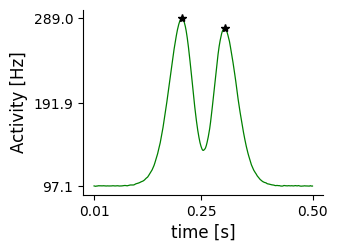

(array([289.05742552, 277.50634345]), 289.0, 138.0, 151.0, 40.0, 72.0)

In [6]:
peak_analysis(PC_005_150, prominence=0.9, t=t, ttrans =100)

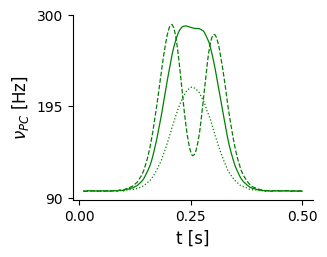

In [7]:
plt.figure(figsize=(3.1, 2.4))
plt.plot(t[100:], PC_005_50[100:], color = 'green', linewidth = 0.9, linestyle = ':')
plt.plot(t[100:], PC_005_100[100:], color = 'green', linewidth = 0.9, linestyle = '-')
plt.plot(t[100:], PC_005_150[100:], color = 'green', linewidth = 0.9, linestyle = '--')

plt.ylabel('$ν_{PC}$ [Hz]', fontsize = 12)
plt.yticks([90, 195, 300])

plt.xticks([ round(np.min(t),2), round(np.max(t)/2,2),  round(np.max(t),2)])
plt.xlabel('t [s]', fontsize = 12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(base_path+'multi_peak_005.pdf', dpi =300, bbox_inches = "tight")
plt.show()

In [39]:
def get_three_ticks(data, variance):
        y_min = np.min(data - np.sqrt(abs(variance)))
        y_max = np.max(data + np.sqrt(abs(variance)))
        y_mid = (y_min + y_max) / 2

        if y_min < 0: y_min=0
        return [round(y_min), round(y_mid), round(y_max)]


def plot_MF_activity_withSD_m(t, X, finput, mytitle, col_vec, alpha, X_ticks, font_size=22, linew=1.5, lines = '-', axes=None):
    """
    Se axes è None, crea una nuova figura con 5 subplot.
    Se axes è passato, disegna sugli assi esistenti.
    """
    if axes is None:
        fig, axes = plt.subplots(5, 1, figsize=(2.4, 4.1))
        fig.suptitle(mytitle, fontsize=font_size + 2)
    else:
        fig = axes[0].figure  # recupera la figura dagli assi

    ax1, ax2, ax3, ax4, ax5 = axes

    # PC
    ax1.plot(t, X[:, 10], col_vec[0], linewidth=linew, alpha=alpha,  linestyle= lines)
    ax1.fill_between(t, X[:, 10] - np.sqrt(abs(X[:, 15])), X[:, 10] + np.sqrt(abs(X[:, 15])),
                     color=col_vec[0], alpha=0.05)
    ax1.set_yticks(X_ticks[0])
    #ax1.set_xticks([])
    ax1.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # MLI
    ax2.plot(t, X[:, 9], col_vec[1], linewidth=linew, alpha=alpha,  linestyle= lines)
    ax2.fill_between(t, X[:, 9] - np.sqrt(abs(X[:, 11])), X[:, 9] + np.sqrt(abs(X[:, 11])),
                     color=col_vec[1], alpha=0.1)
    ax2.set_yticks(X_ticks[1])
    ax2.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # GoC
    ax3.plot(t, X[:, 1], col_vec[2], linewidth=linew, alpha=alpha, linestyle= lines)
    ax3.fill_between(t, X[:, 1] - np.sqrt(abs(X[:, 6])), X[:, 1] + np.sqrt(abs(X[:, 6])),
                     color=col_vec[2], alpha=0.05)
    ax3.set_ylabel(r'$\nu$ [Hz]', fontsize=font_size, ha='center', va='center', labelpad=20)
    ax3.set_yticks(X_ticks[2])
    ax3.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # GrC
    ax4.plot(t, X[:, 0], col_vec[3], linewidth=linew, alpha=alpha,  linestyle= lines)
    ax4.fill_between(t, X[:, 0] - np.sqrt(abs(X[:, 2])), X[:, 0] + np.sqrt(abs(X[:, 2])),
                     color=col_vec[3], alpha=0.1)
    ax4.set_yticks(X_ticks[3])
    ax4.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # Input (solo una volta, ma se vuoi puoi plottarlo più volte)
    ax5.plot(t, finput, 'black', linewidth=linew, alpha = alpha, linestyle=lines)
    ax5.set_yticks(X_ticks[4])
    ax5.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))
    ax5.set_xlabel('t [s]', fontsize=font_size, ha='center', va='center', labelpad=20)

    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.subplots_adjust(hspace=0.5, top=0.92, bottom=0.1)

    return fig, axes

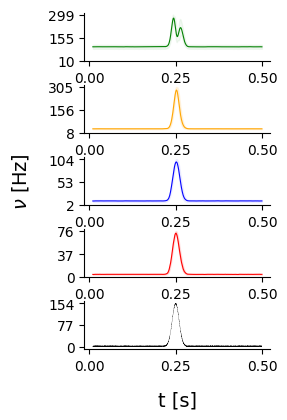

In [35]:
X_gauss = data_001_150
f_gauss_back = inp_txt_001_150
# f_gauss = inp_txt ## need to add the return to the function!
X_ticks_PC=get_three_ticks(X_gauss[:, 10], X_gauss[:, 15])
X_ticks_MLI = get_three_ticks(X_gauss[:, 9], X_gauss[:, 11])
X_ticks_GoC = get_three_ticks(X_gauss[:, 1], X_gauss[:, 6])
X_ticks_GrC = get_three_ticks(X_gauss[:, 0], X_gauss[:, 2])
X_ticks_input = get_three_ticks(f_gauss_back, np.zeros_like(f_gauss_back))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig_stim, axes_stim = plot_MF_activity_withSD_m(t[100:], X_gauss[100:,:], f_gauss_back[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.8)

#fig_stim.savefig('NEW_gauss_stim'+str(sigma)+str(amp)+'.png', dpi=300, bbox_inches="tight")

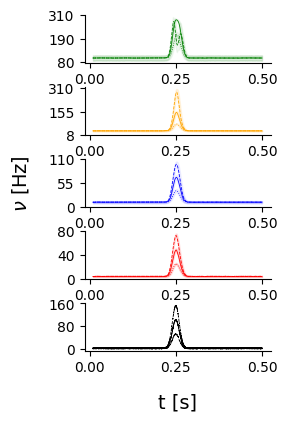

In [40]:
X_ticks_input = [0, 80, 160]
X_ticks_GrC = [0, 40, 80]
X_ticks_GoC = [0, 55, 110]
X_ticks_MLI = [8, 155, 310]
X_ticks_PC = [80, 190, 310]
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]


fig_stim, axes_stim = plot_MF_activity_withSD_m(t[100:], data_001_50[100:,:], inp_txt_001_50[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines=':')

plot_MF_activity_withSD_m(t[100:], data_001_100[100:,:], inp_txt_001_100[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines = '-', axes=axes_stim)

plot_MF_activity_withSD_m(t[100:], data_001_150[100:,:], inp_txt_001_150[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines ='--', axes=axes_stim)


fig_stim.savefig(base_path+'gauss_stim_001.png', dpi=300, bbox_inches="tight")

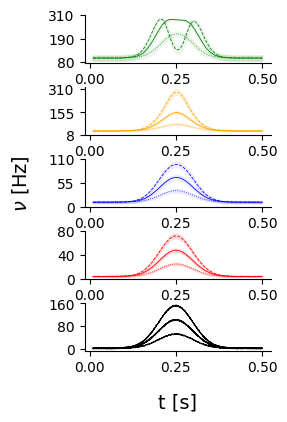

In [41]:
fig_stim005, axes_stim005 = plot_MF_activity_withSD_m(t[100:], data_005_50[100:,:], inp_txt_005_50[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines=':')

plot_MF_activity_withSD_m(t[100:], data_005_100[100:,:], inp_txt_005_100[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines = '-', axes=axes_stim005)

plot_MF_activity_withSD_m(t[100:], data_005_150[100:,:], inp_txt_005_150[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines ='--', axes=axes_stim005)


fig_stim005.savefig(base_path+'gauss_stim_005.png', dpi=300, bbox_inches="tight")

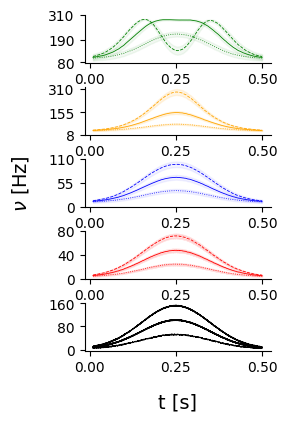

In [42]:
fig_stim01, axes_stim01 = plot_MF_activity_withSD_m(t[100:], data_01_50[100:,:], inp_txt_01_50[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines=':')

plot_MF_activity_withSD_m(t[100:], data_01_100[100:,:], inp_txt_01_100[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines = '-', axes=axes_stim01)

plot_MF_activity_withSD_m(t[100:], data_01_150[100:,:], inp_txt_01_150[100:], "",
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.6, lines ='--', axes=axes_stim01)


fig_stim01.savefig(base_path+'gauss_stim_01.png', dpi=300, bbox_inches="tight")

## References:

- Cerebellar MF model: Lorenzi et al. 2023 (https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011434)
- E-GLIF: Geminiani et al. 2018, 2019 (https://doi.org/10.3389/fninf.2018.00088 and https://doi.org/10.3389/fncom.2019.00035)
- BSB: De Schepper et al. 2022 (https://doi.org/10.1038/s42003-022-04213-y)
- Mathematics: Boustani and Destexhe 2009 (https://doi.org/10.1162/neco.2009.02-08-710)
- TF formalism: Zerlaut et al. 2018 (https://doi.org/10.1007/s10827-017-0668-2)
- TF Fitting procedure: Zerlaut et al. 2016  (https://doi.org/10.1113/JP272317)
- MF with adaptation: Di Volo et al. 2019 (https://doi.org/10.1162/neco_a_01173)
- MF review for different neuron model: Carlu et al. 2020 (https://doi.org/10.1152/jn.00399.2019)